    Instructions:
    1. Run task_2.py to generate the tensor database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide an image ID and a k value.


    Task 3: Implement a program which, given an image ID and a value “k”, returns and visualizes the most similar k images
    based on each of the visual model -you will select the appropriate distance/similarity measure for each feature model.
    For each match, also list the corresponding distance/similarity score.

In [7]:
# Initialize dataset, downloads into <git_root>/Code/caltech101 if not present. Untracked by git.

import os
from torchvision.datasets import Caltech101

dataset = Caltech101(root=os.path.abspath(""), download=True)

Files already downloaded and verified


Input image:
Image ID:  2500


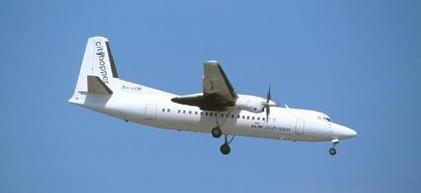

Category: airplanes


In [8]:
# Find the k most similar images for a given Image ID for each feature model.

IMG_ID = int(input("Provide an Image ID in the Caltech101 dataset in range [0, 8676]."))

image, category = dataset[IMG_ID][0], dataset.categories[dataset[IMG_ID][1]]

if image.mode != 'RGB':
    print(
    """
    WARNING: The provided image does not have RGB channels, the image will be converted to RGB.
    Note: The vector database does not contain the vectors of non-RGB images, the closest RGB
          matches will be provided instead.
    """
    )
    image = image.convert('RGB')

K = int(input("Enter K, the number of similar images K to find for each feature model."))

print("Input image:\nImage ID: ", IMG_ID)
display(image)
print("Category:", category)

In [9]:
# Resize to 300x100 and partition to grid.

from torchvision.transforms import Resize

image300x100 = Resize(size=(100, 300))(image)

from utils.utilities import partition_to_grid

grid = partition_to_grid(image300x100, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

Similar images by Color Moments:
1. 	Image ID:  2500 		Distance:  0.0


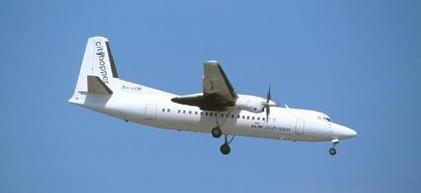

2. 	Image ID:  2301 		Distance:  647.0774536132812


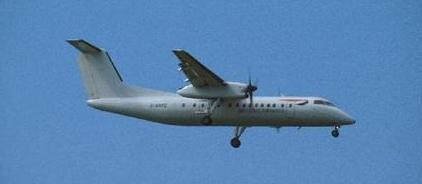

3. 	Image ID:  2519 		Distance:  662.104248046875


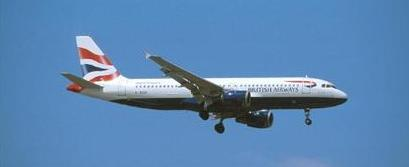

In [10]:
# Color moments (CM10x10).

# Find K most similar images by color moments.

from feature_extractors.color_moments import get_color_vector

color_vector = get_color_vector(grid)

# Load color tensor database into memory.

from utils.utilities import tensor_loader

color_tensor_dict = tensor_loader('color_tensors.pt', os.path.abspath(""))

# TODO: Either justify or pick a different distance measure.

from scipy.spatial.distance import euclidean

from utils.utilities import top_k_ranker

top_k_by_color = top_k_ranker(K, color_vector, color_tensor_dict, euclidean)

print("Similar images by Color Moments:")

for i in range(len(top_k_by_color)):

    id = top_k_by_color[i][1]
    distance = top_k_by_color[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])

In [11]:
# Convert to grayscale and partition to grid.

from torchvision.transforms import Grayscale

gs_image = Grayscale()(image300x100)

gs_grid = partition_to_grid(gs_image, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

Similar images by Histogram of Oriented Gradients (HOG):
1. 	Image ID:  2500 		Distance:  0


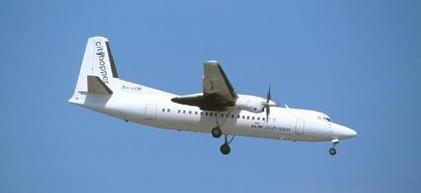

2. 	Image ID:  2121 		Distance:  0.02785143359164821


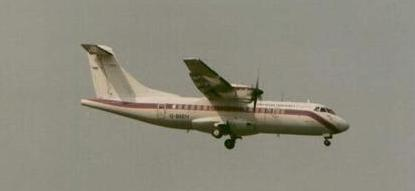

3. 	Image ID:  2308 		Distance:  0.0302071570834197


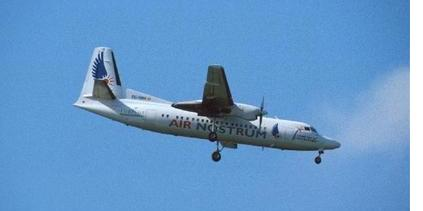

In [12]:
# Histograms of oriented gradients (HOG).

# Find K most similar images by HOG.

from feature_extractors.HOG import get_hog_vector

hog_vector = get_hog_vector(gs_grid)

# Load hog tensor database into memory.

hog_tensor_dict = tensor_loader('hog_tensors.pt', os.path.abspath(""))

# TODO: Either justify or pick a different distance measure.

from scipy.spatial.distance import cosine

top_k_by_hog = top_k_ranker(K, hog_vector, hog_tensor_dict, cosine)

print("Similar images by Histogram of Oriented Gradients (HOG):")

for i in range(len(top_k_by_hog)):

    id = top_k_by_hog[i][1]
    distance = top_k_by_hog[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])


In [13]:
# Resize original image to 224x224 and convert to float tensor.

from torchvision.transforms import transforms

image224x224 = Resize(size=(224, 224))(image)

img_tensor = transforms.Compose([transforms.ToTensor()])(image224x224)

In [14]:
# ResNet pre-processing.

# Find K most similar images by each of the 3 layers chosen from ResNet-50.

from feature_extractors.resnet_50 import get_resnet50_feature_vectors

avgpool_vector, layer3_vector, fc1000_vector = get_resnet50_feature_vectors(img_tensor)

# Load each tensor database into memory

avgpool_tensor_dict = tensor_loader('avgpool_tensors.pt', os.path.abspath(""))
layer3_tensor_dict = tensor_loader('layer3_tensors.pt', os.path.abspath(""))
fc1000_tensor_dict = tensor_loader('fc1000_tensors.pt', os.path.abspath(""))

Similar images by ResNet-AvgPool-1024:
1. 	Image ID:  2500 		Distance:  0.0


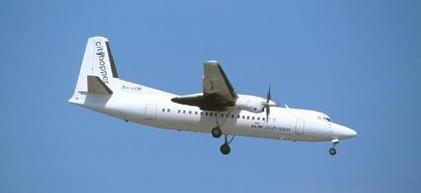

2. 	Image ID:  2308 		Distance:  1.289465308189392


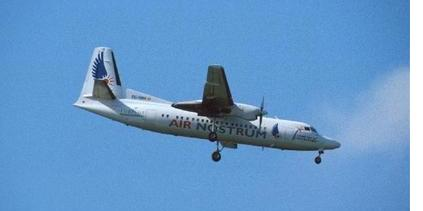

3. 	Image ID:  2167 		Distance:  1.5562258958816528


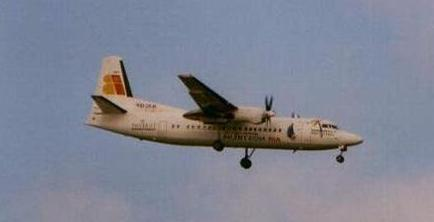

In [15]:
# ResNet-AvgPool-1024.

# Find K most similar images by ResNet-AvgPool-1024.

# TODO: Either justify or pick a different distance measure.

from scipy.spatial.distance import euclidean

top_k_by_avgpool = top_k_ranker(K, avgpool_vector, avgpool_tensor_dict, euclidean)

print("Similar images by ResNet-AvgPool-1024:")

for i in range(len(top_k_by_avgpool)):

    id = top_k_by_avgpool[i][1]
    distance = top_k_by_avgpool[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])

Similar images by ResNet-Layer3-1024:
1. 	Image ID:  2500 		Distance:  0.0


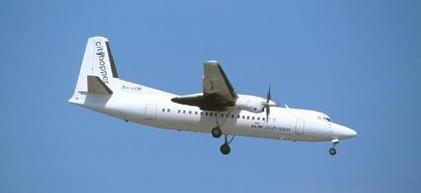

2. 	Image ID:  2519 		Distance:  3.208758592605591


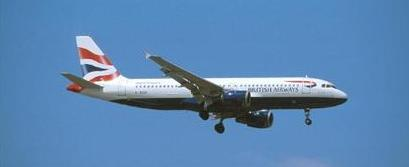

3. 	Image ID:  2217 		Distance:  3.511819839477539


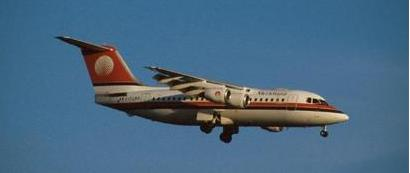

In [16]:
# ResNet-Layer3-1024.

# Find K most similar images by ResNet-Layer3-1024.

# TODO: Either justify or pick a different distance measure.

from scipy.spatial.distance import euclidean

top_k_by_layer3 = top_k_ranker(K, layer3_vector, layer3_tensor_dict, euclidean)

print("Similar images by ResNet-Layer3-1024:")

for i in range(len(top_k_by_layer3)):

    id = top_k_by_layer3[i][1]
    distance = top_k_by_layer3[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])

Similar images by ResNet-FC-1000:
1. 	Image ID:  2500 		Distance:  0.0


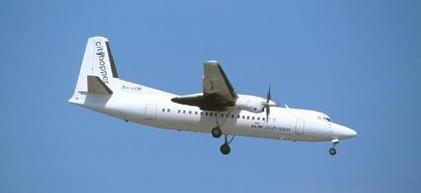

2. 	Image ID:  2308 		Distance:  3.9115116596221924


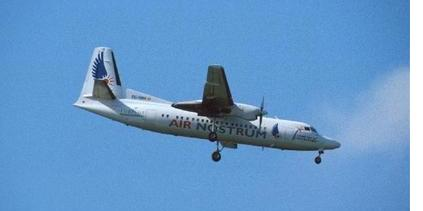

3. 	Image ID:  2167 		Distance:  4.4707489013671875


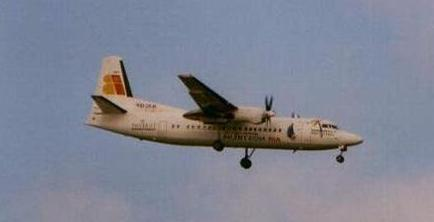

In [17]:
# ResNet-FC-1000.

# Find K most similar images by ResNet-FC-1000.

# TODO: Either justify or pick a different distance measure.

from scipy.spatial.distance import euclidean

top_k_by_fc1000 = top_k_ranker(K, fc1000_vector, fc1000_tensor_dict, euclidean)

print("Similar images by ResNet-FC-1000:")

for i in range(len(top_k_by_fc1000)):

    id = top_k_by_fc1000[i][1]
    distance = top_k_by_fc1000[i][0]

    print(str(i + 1) + ".", "\tImage ID: ", id, "\t\tDistance: ", distance)
    display(dataset[id][0])